# Préparation des données Parcoursup

Ce bloc prépare une base propre avant l'analyse uni-dimensionnelle :
- chargement des données,
- sélection des variables utiles,
- création d'indicateurs simples et interprétables pour l'analyse.


In [1]:
library(tidyverse)

# lecture du CSV Parcoursup (sep=';' car format français, check.names pour noms exploitables en R)
data <- read.csv('Parcoursup.csv', sep = ';', header = TRUE, stringsAsFactors = FALSE, check.names = TRUE)

# Contrôle minimal : nombre de lignes/colonnes + aperçu de 3 lignes
dim(data)
head(data, 3)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] 14252   118

,Session,Statut.de.l.établissement.de.la.filière.de.formation..public..privé..,Code.UAI.de.l.établissement,Établissement,Code.départemental.de.l.établissement,Département.de.l.établissement,Région.de.l.établissement,Académie.de.l.établissement,Commune.de.l.établissement,Filière.de.formation,⋯,tri,cod_aff_form,Concours.communs.et.banque.d.épreuves,Lien.de.la.formation.sur.la.plateforme.Parcoursup,Taux.d.accès,Part.des.terminales.générales.qui.étaient.en.position.de.recevoir.une.proposition.en.phase.principale,Part.des.terminales.technologiques.qui.étaient.en.position.de.recevoir.une.proposition.en.phase.principale,Part.des.terminales.professionnelles.qui.étaient.en.position.de.recevoir.une.proposition.en.phase.principale,etablissement_id_paysage,composante_id_paysage
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>
1,2025,Public,0692185A,INSTITUT DES SCIENCES ET TECHNIQUES DE LA READAPTATION UNIVERSITE LYON 1,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 8e Arrondissement,Certificat de capacité d'Orthoptiste,⋯,3_Autres formations,28087,Aix-Marseille Université - Site de Marseille Timone,https://dossierappel.parcoursup.fr/Candidats/public/fiches/afficherFicheFormation?g_ta_cod=28087&typeBac=0&originePc=0,13,93,7,1,NA,NA
2,2025,Public,0931827F,Université Paris 8,93,Seine-Saint-Denis,Ile-de-France,Créteil,Saint-Denis,Licence - Langues étrangères appliquées - Parcours Anglais / Italien,⋯,1_universités,28100,,https://dossierappel.parcoursup.fr/Candidats/public/fiches/afficherFicheFormation?g_ta_cod=28100&typeBac=0&originePc=0,98,57,24,19,NA,NA
3,2025,Public,0421573G,IFSI du CH de Roanne,42,Loire,Auvergne-Rhône-Alpes,Lyon,Roanne,D.E Infirmier,⋯,3_Autres formations,28144,,https://dossierappel.parcoursup.fr/Candidats/public/fiches/afficherFicheFormation?g_ta_cod=28144&typeBac=0&originePc=0,40,56,37,7,NA,NA


## Vérification rapide

On vérifie la structure globale sans multiplier les diagnostics : dimensions, types et quelques statistiques de base.


In [2]:
# Vue d'ensemble des types de variables (numériques, caractères, etc.)
glimpse(data)

# Résumé ciblé sur des variables de volume utiles pour la suite
summary(select(data,
  Capacité.de.l.établissement.par.formation,
  Effectif.total.des.candidats.pour.une.formation,
  Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis.
))


Rows: 14,252
Columns: 118
$ Session                                                                                                                                          <int> …
$ Statut.de.l.établissement.de.la.filière.de.formation..public..privé..                                                                            <chr> …
$ Code.UAI.de.l.établissement                                                                                                                      <chr> …
$ Établissement                                                                                                                                    <chr> …
$ Code.départemental.de.l.établissement                                                                                                            <chr> …
$ Département.de.l.établissement                                                                                                                   <chr> …
$ Région.de.l.établissement                 

 Capacité.de.l.établissement.par.formation
 Min.   :   0.00                          
 1st Qu.:  18.00                          
 Median :  30.00                          
 Mean   :  53.98                          
 3rd Qu.:  50.00                          
 Max.   :3400.00                          
 Effectif.total.des.candidats.pour.une.formation
 Min.   :    1.0                                
 1st Qu.:  160.0                                
 Median :  385.0                                
 Mean   :  947.4                                
 3rd Qu.: 1016.0                                
 Max.   :19404.0                                
 Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis.
 Min.   :   0.00                                                                     
 1st Qu.:  14.00                                                                     
 Median :  25.00                                                                     
 Mean   :  4

## Nettoyage et variables construites

Logique du nettoyage :
- retirer les colonnes techniques ou trop fines pour l'objectif (identifiants, GPS, liens, détails redondants),
- conserver les colonnes utiles à l'analyse genre/sélectivité/profil des admis,
- construire des variables agrégées simples (2 phases, pourcentages de genre, parts de mentions).


In [3]:
# Colonnes retirées : identifiants techniques, géographie trop fine, détails redondants
cols_to_drop <- c(
  'Session',
  'Code.UAI.de.l.établissement',
  'Code.départemental.de.l.établissement',
  'Département.de.l.établissement',
  'Coordonnées.GPS.de.la.formation',
  'Commune.de.l.établissement',
  'Filière.de.formation.détaillée',
  'Filière.de.formation.détaillée.bis',
  'Filière.de.formation.très.détaillée',
  'Dont.effectif.des.candidats.ayant.postulé.en.internat',
  'Effectif.total.des.candidats.classés.par.l.établissement.en.phase.principale',
  'Effectif.des.candidats.classés.par.l.établissement.en.phase.complémentaire',
  'Effectif.des.candidats.classés.par.l.établissement.en.internat..CPGE.',
  'Effectif.des.candidats.classés.par.l.établissement.hors.internat..CPGE.',
  'Concours.communs.et.banque.d.épreuves',
  'cod_aff_form',
  'Lien.de.la.formation.sur.la.plateforme.Parcoursup',
  'etablissement_id_paysage',
  'composante_id_paysage'
)

# any_of : évite une erreur si une colonne listée est absente
data <- data %>%
  select(-any_of(cols_to_drop))

# Colonnes converties en numérique avant calcul de ratios
num_cols <- c(
  'Capacité.de.l.établissement.par.formation',
  'Effectif.total.des.candidats.en.phase.principale',
  'Effectif.total.des.candidats.en.phase.complémentaire',
  'Effectif.des.admis.en.phase.principale',
  'Effectif.des.admis.en.phase.complémentaire',
  'Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis.',
  'Dont.effectif.des.candidates.admises',
  'Effectif.des.admis.néo.bacheliers',
  'Dont.effectif.des.admis.néo.bacheliers.sans.mention.au.bac',
  'Dont.effectif.des.admis.néo.bacheliers.avec.mention.Assez.Bien.au.bac',
  'Dont.effectif.des.admis.néo.bacheliers.avec.mention.Bien.au.bac',
  'Dont.effectif.des.admis.néo.bacheliers.avec.mention.Très.Bien.au.bac',
  'Dont.effectif.des.admis.néo.bacheliers.avec.mention.Très.Bien.avec.félicitations.au.bac'
)

data <- data %>%
  # across(...): applique as.numeric à toutes les colonnes de num_cols
  mutate(across(any_of(num_cols), ~ suppressWarnings(as.numeric(.x)))) %>%
  mutate(
    # Agrégation des volumes sur les deux phases d'admission
    Effectif.total.candidats.2phases = coalesce(Effectif.total.des.candidats.en.phase.principale, 0) +
      coalesce(Effectif.total.des.candidats.en.phase.complémentaire, 0),
    Effectif.total.admis.2phases = coalesce(Effectif.des.admis.en.phase.principale, 0) +
      coalesce(Effectif.des.admis.en.phase.complémentaire, 0),
      #coalesce remplace les valeurs manquantes par 0

    # Parts filles/garçons parmi les admis (entre 0 et 1)
    pct_filles_admises = if_else(
      Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis. > 0,
      Dont.effectif.des.candidates.admises / Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis.,
      NA_real_
    ),
    pct_garcons_admis = if_else(!is.na(pct_filles_admises), 1 - pct_filles_admises, NA_real_),

    # Parts de mentions parmi les admis néo-bacheliers
    part_mention_ab = if_else(Effectif.des.admis.néo.bacheliers > 0,
      Dont.effectif.des.admis.néo.bacheliers.avec.mention.Assez.Bien.au.bac / Effectif.des.admis.néo.bacheliers, NA_real_),
    part_mention_b = if_else(Effectif.des.admis.néo.bacheliers > 0,
      Dont.effectif.des.admis.néo.bacheliers.avec.mention.Bien.au.bac / Effectif.des.admis.néo.bacheliers, NA_real_),
    part_mention_tb = if_else(Effectif.des.admis.néo.bacheliers > 0,
      Dont.effectif.des.admis.néo.bacheliers.avec.mention.Très.Bien.au.bac / Effectif.des.admis.néo.bacheliers, NA_real_),
    part_mention_tb_fel = if_else(Effectif.des.admis.néo.bacheliers > 0,
      Dont.effectif.des.admis.néo.bacheliers.avec.mention.Très.Bien.avec.félicitations.au.bac / Effectif.des.admis.néo.bacheliers, NA_real_)
  )


## Features principales pour l'analyse

On crée un jeu de features simple et cohérent avec le cours : ratios interprétables, transformations log des volumes et discrétisation par quantiles.


In [ ]:
# Conversion de Taux.d.accès (texte) en proportion numérique [0,1]
data <- data %>%
  mutate(
    taux_acces_num = suppressWarnings(as.numeric(gsub(',', '.', gsub('%', '', Taux.d.accès)))) / 100
  )

data_features_core <- data %>%
  mutate(
    # Intensité de la demande vs places disponibles
    pression_candidature = if_else(Capacité.de.l.établissement.par.formation > 0,
      Effectif.total.candidats.2phases / Capacité.de.l.établissement.par.formation, NA_real_),

    # Probabilité d'être admis parmi les candidats
    taux_admission = if_else(Effectif.total.candidats.2phases > 0,
      Effectif.total.admis.2phases / Effectif.total.candidats.2phases, NA_real_),

    # Niveau de remplissage de la capacité
    taux_remplissage = if_else(Capacité.de.l.établissement.par.formation > 0,  
      Effectif.total.admis.2phases / Capacité.de.l.établissement.par.formation, NA_real_),

    # Regroupement des meilleures mentions
    part_mention_haute = part_mention_tb + part_mention_tb_fel,

    # Score synthétique (pondération croissante avec le niveau de mention)
    score_mention = 1 * coalesce(part_mention_ab, 0) +
      2 * coalesce(part_mention_b, 0) +
      3 * coalesce(part_mention_tb, 0) +
      4 * coalesce(part_mention_tb_fel, 0),

    # log1p stabilise les variables de volume très asymétriques
    log_candidats = log1p(Effectif.total.candidats.2phases),
    log_admis = log1p(Effectif.total.admis.2phases),
    log_capacite = log1p(Capacité.de.l.établissement.par.formation),

    # Discrétisation en quartiles (1 = faible, 4 = élevé)
    pression_q = ntile(pression_candidature, 4),
    taux_acces_q = ntile(taux_acces_num, 4)
  ) %>%
  # Sélection du sous-ensemble de variables pour l'analyse
  select(
    Établissement, Filière.de.formation, Filière.de.formation.très.agrégée,
    Région.de.l.établissement, Académie.de.l.établissement, Sélectivité,
    pct_filles_admises, pct_garcons_admis,
    pression_candidature, taux_admission, taux_remplissage, taux_acces_num,
    part_mention_ab, part_mention_b, part_mention_tb, part_mention_tb_fel, part_mention_haute, score_mention,
    log_candidats, log_admis, log_capacite,
    pression_q, taux_acces_q
  )

# Vérification rapide du jeu de features final
glimpse(data_features_core)
summary(select(data_features_core, where(is.numeric)))


Rows: 14,252
Columns: 23
$ Établissement                     <chr> "INSTITUT DES SCIENCES ET TECHNIQUES…
$ Filière.de.formation              <chr> "Certificat de capacité d'Orthoptist…
$ Filière.de.formation.très.agrégée <chr> "Autre formation", "Licence", "IFSI"…
$ Région.de.l.établissement         <chr> "Auvergne-Rhône-Alpes", "Ile-de-Fran…
$ Académie.de.l.établissement       <chr> "Lyon", "Créteil", "Lyon", "Lyon", "…
$ Sélectivité                       <chr> "formation sélective", "formation no…
$ pct_filles_admises                <dbl> 0.8250000, 0.7666667, 0.8928571, 0.5…
$ pct_garcons_admis                 <dbl> 0.17500000, 0.23333333, 0.10714286, …
$ pression_candidature              <dbl> 23.400000, 7.781250, 49.839286, 30.6…
$ taux_admission                    <dbl> 0.042735043, 0.120481928, 0.02006449…
$ taux_remplissage                  <dbl> 1.0000000, 0.9375000, 1.0000000, 0.9…
$ taux_acces_num                    <dbl> 0.13, 0.98, 0.40, 0.36, 0.20, NA, 0.…
$ part_mention_

 pct_filles_admises pct_garcons_admis pression_candidature taux_admission   
 Min.   :0.0000     Min.   :0.0000    Min.   :  0.050      Min.   :0.00000  
 1st Qu.:0.2613     1st Qu.:0.2500    1st Qu.:  6.171      1st Qu.:0.03618  
 Median :0.5357     Median :0.4643    Median : 11.417      Median :0.07007  
 Mean   :0.5063     Mean   :0.4937    Mean   : 21.104      Mean   :0.08753  
 3rd Qu.:0.7500     3rd Qu.:0.7387    3rd Qu.: 23.500      3rd Qu.:0.11996  
 Max.   :1.0000     Max.   :1.0000    Max.   :904.667      Max.   :1.00000  
 NA's   :179        NA's   :179       NA's   :4                             
 taux_remplissage taux_acces_num  part_mention_ab  part_mention_b   
 Min.   :0.0000   Min.   :0.010   Min.   :0.0000   Min.   :0.00000  
 1st Qu.:0.7312   1st Qu.:0.330   1st Qu.:0.2308   1st Qu.:0.09091  
 Median :0.9333   Median :0.580   Median :0.3333   Median :0.18182  
 Mean   :0.8356   Mean   :0.583   Mean   :0.3334   Mean   :0.21501  
 3rd Qu.:1.0000   3rd Qu.:0.860   3rd Q

# Analyse uni-dimensionnelle des variables

   Length     Class      Mode 
    14252 character character 

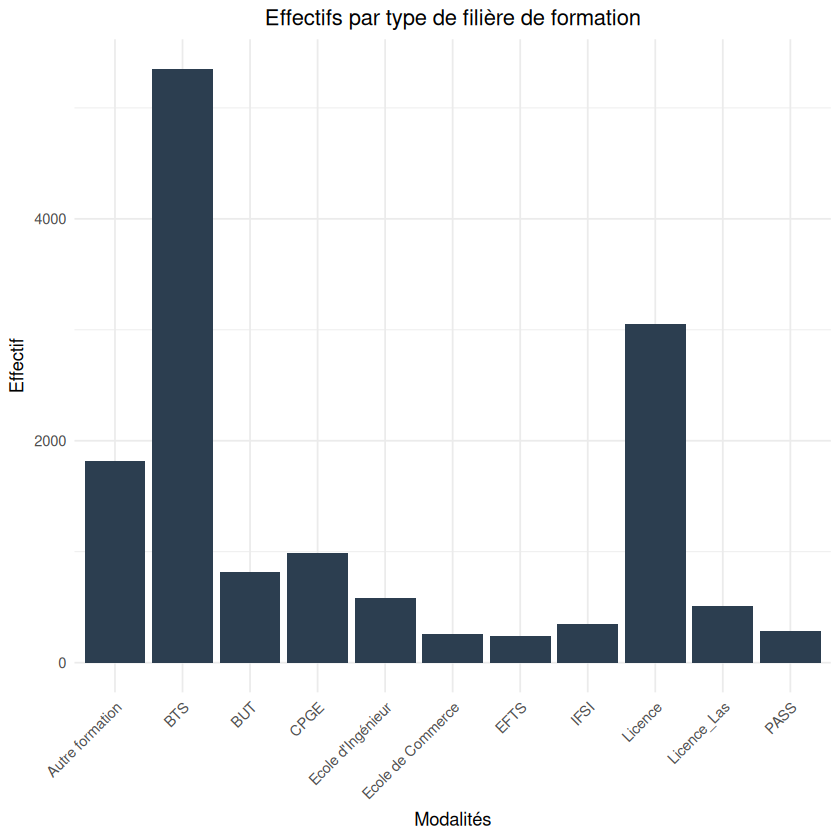

In [5]:
###Effectif par formation
summary(data_features_core$`Filière.de.formation.très.agrégée`)
library(ggplot2)

ggplot(data_features_core, aes(x = `Filière.de.formation.très.agrégée`)) +
  geom_bar(fill = "#2C3E50") +
  labs(
    title = "Effectifs par type de filière de formation",
    x = "Modalités",
    y = "Effectif"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

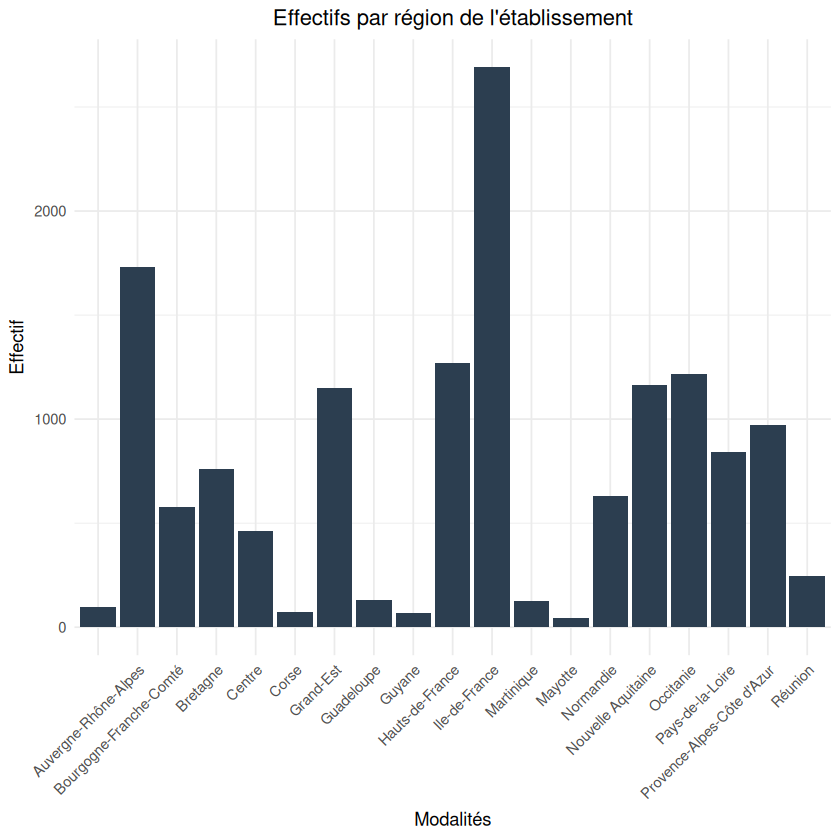

In [6]:
###Effectifs par région
ggplot(data_features_core, aes(x = Région.de.l.établissement)) +
  geom_bar(fill = "#2C3E50") +
  labs(
    title = "Effectifs par région de l'établissement",
    x = "Modalités",
    y = "Effectif"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_density()`).”


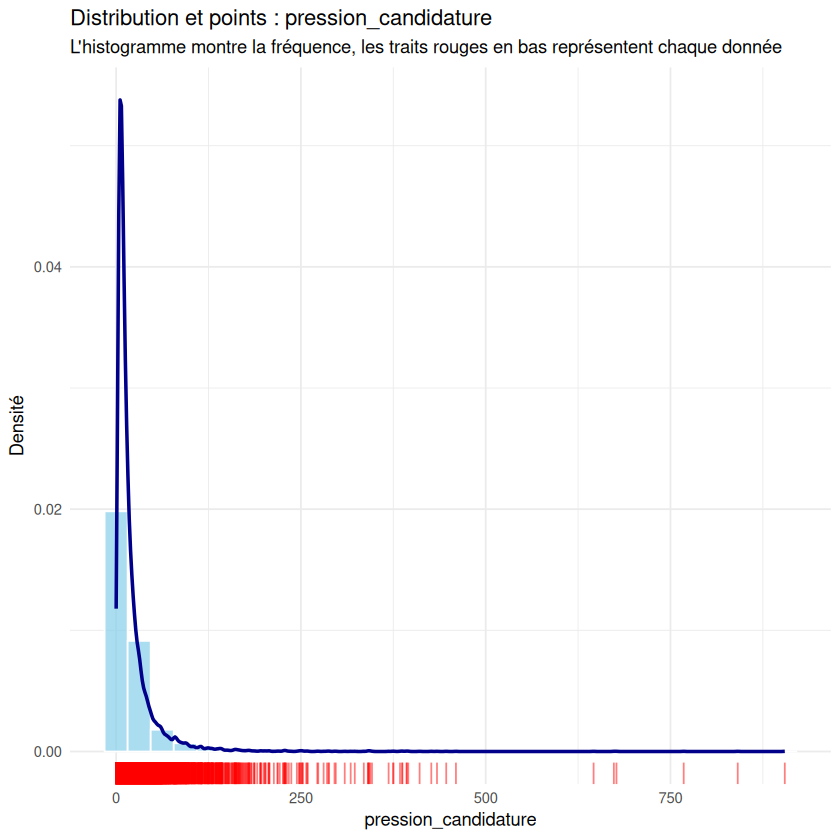

Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_density()`).”


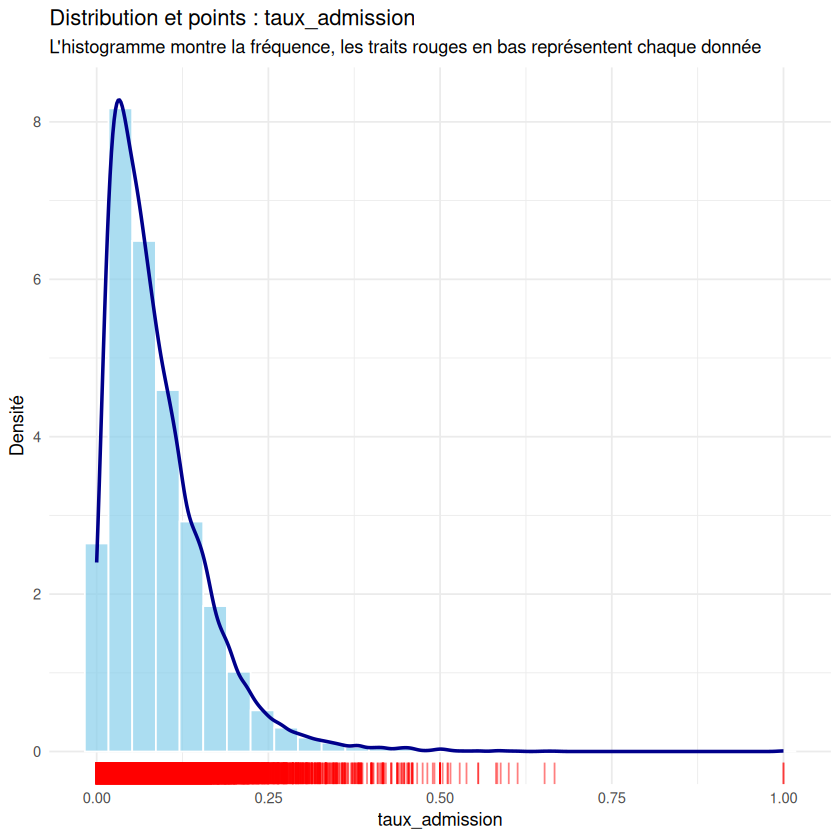

Warning message:
“Removed 1176 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 1176 rows containing non-finite outside the scale range
(`stat_density()`).”


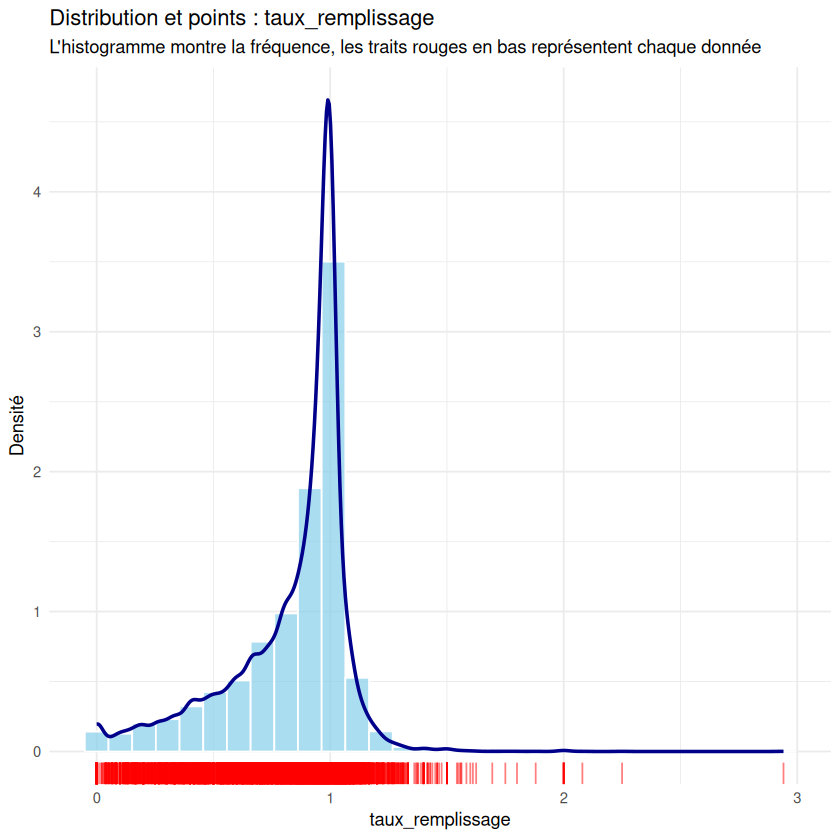

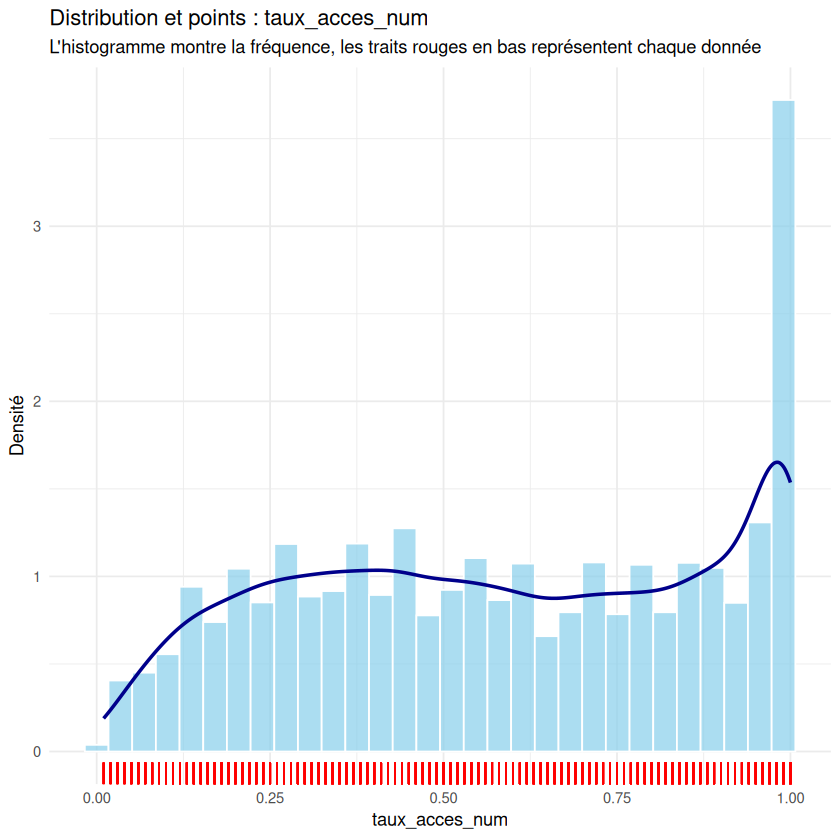

Warning message:
“Removed 179 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 179 rows containing non-finite outside the scale range
(`stat_density()`).”


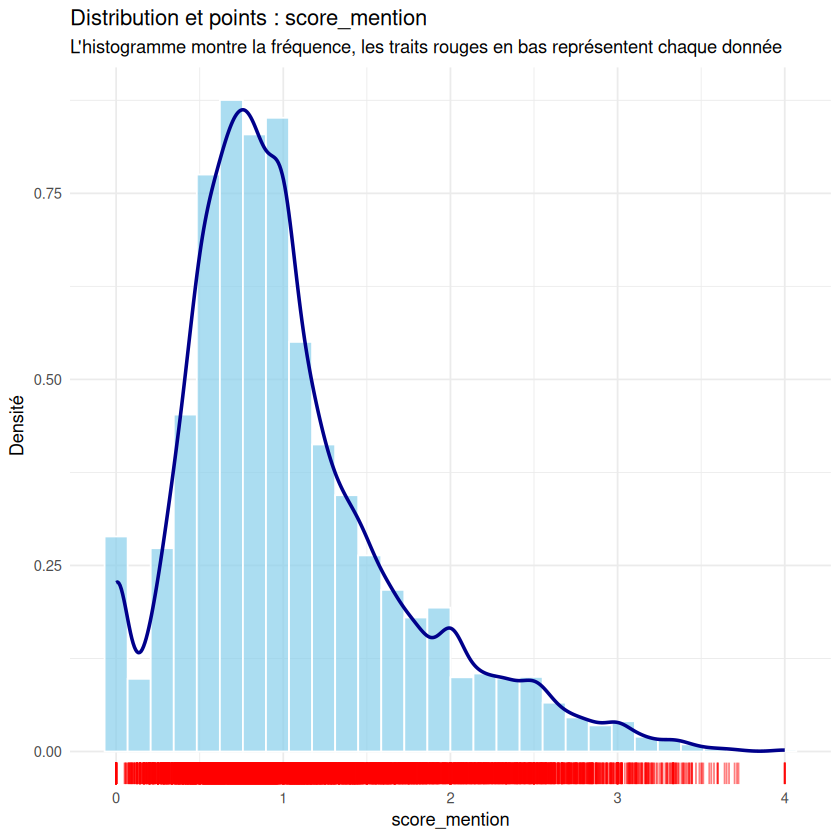

Warning message:
“Removed 179 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 179 rows containing non-finite outside the scale range
(`stat_density()`).”


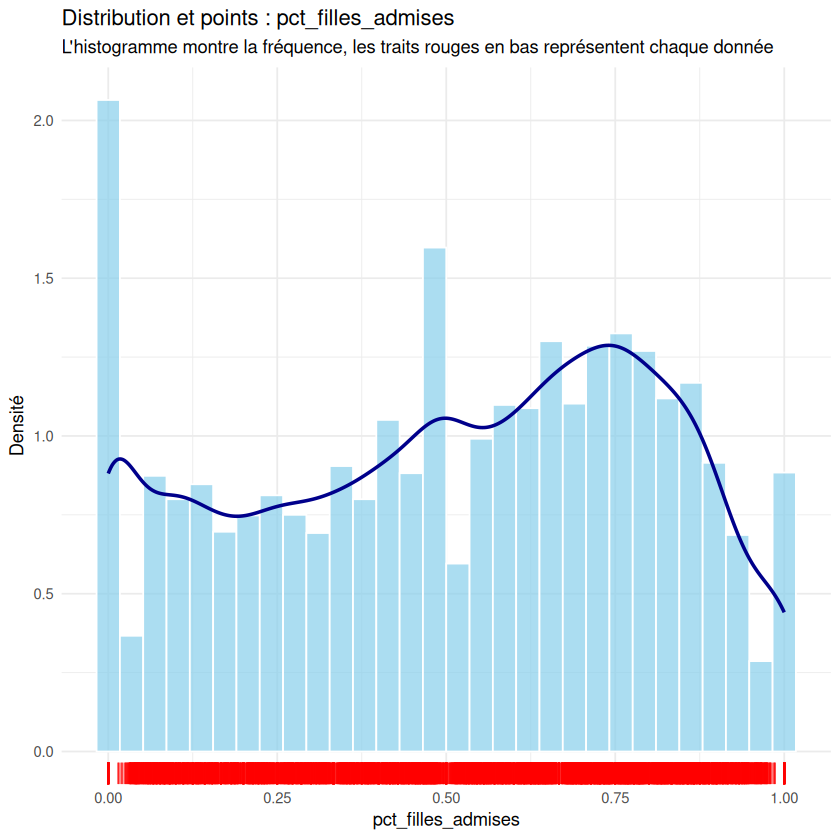

Warning message:
“Removed 298 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 298 rows containing non-finite outside the scale range
(`stat_density()`).”


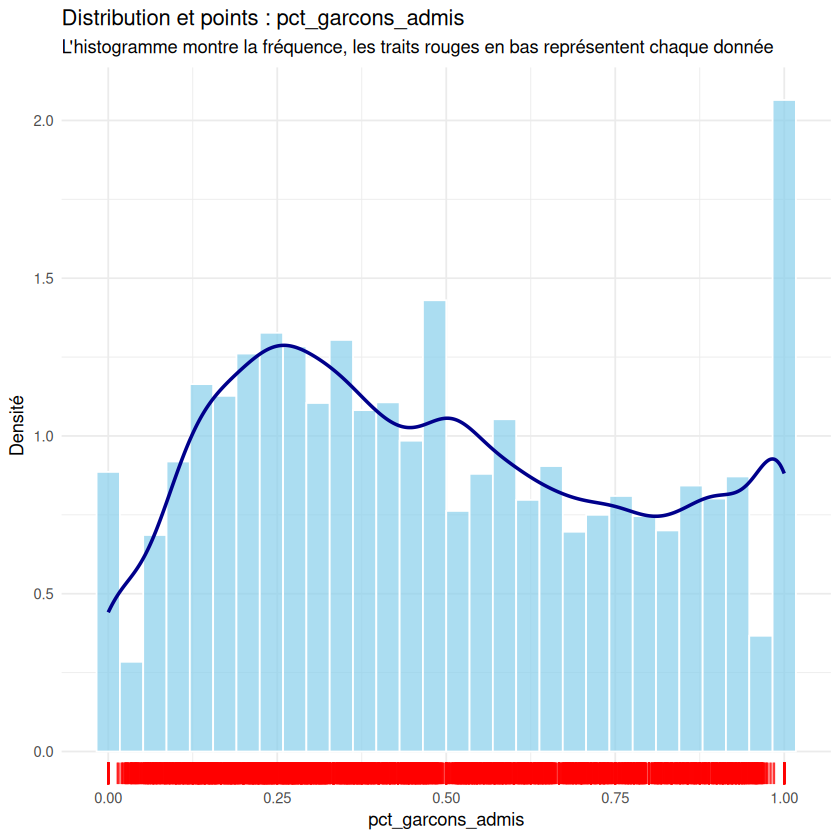

Warning message:
“Removed 298 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 298 rows containing non-finite outside the scale range
(`stat_density()`).”


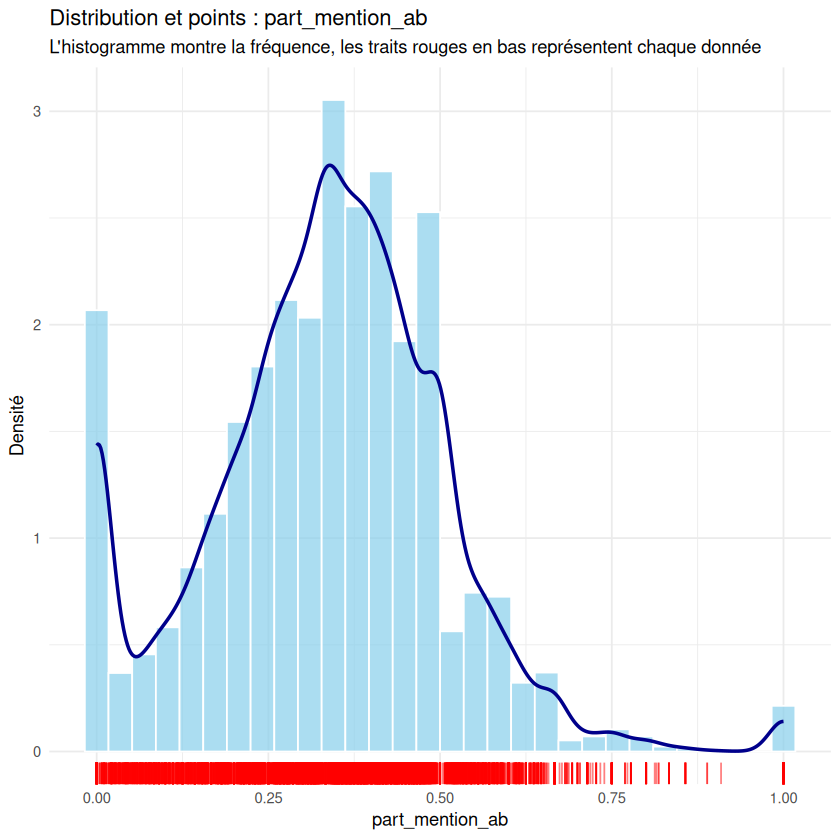

Warning message:
“Removed 298 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 298 rows containing non-finite outside the scale range
(`stat_density()`).”


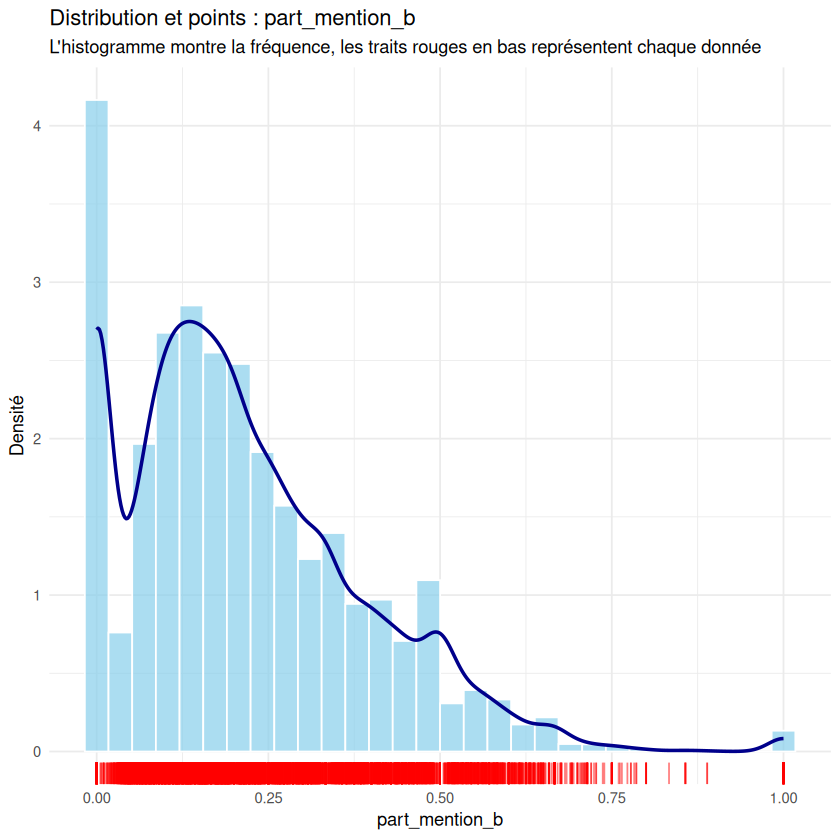

Warning message:
“Removed 298 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 298 rows containing non-finite outside the scale range
(`stat_density()`).”


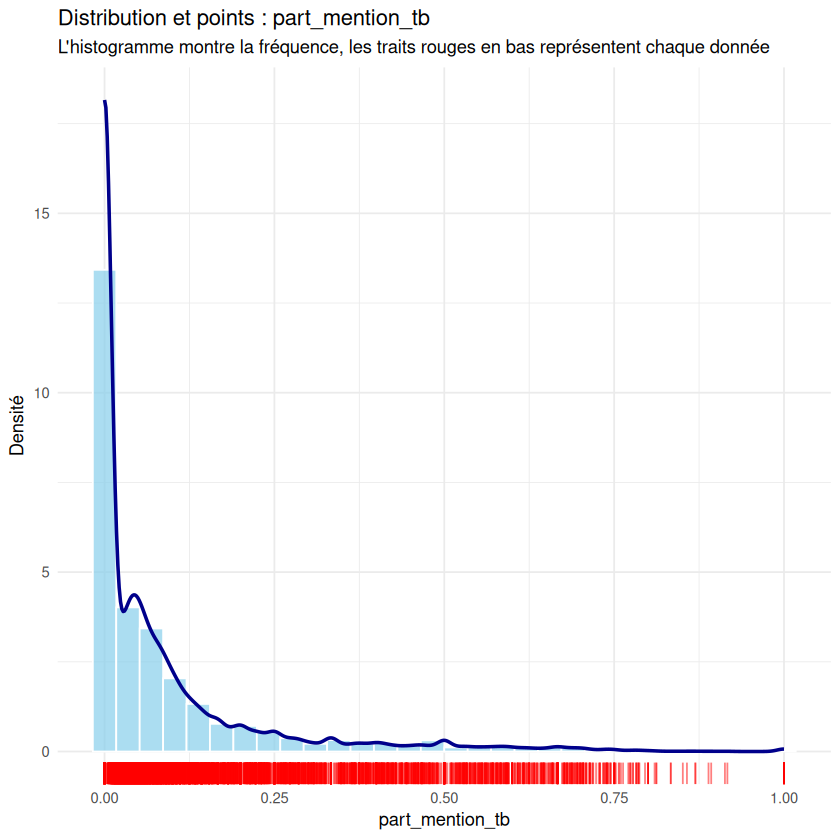

Warning message:
“Removed 298 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 298 rows containing non-finite outside the scale range
(`stat_density()`).”


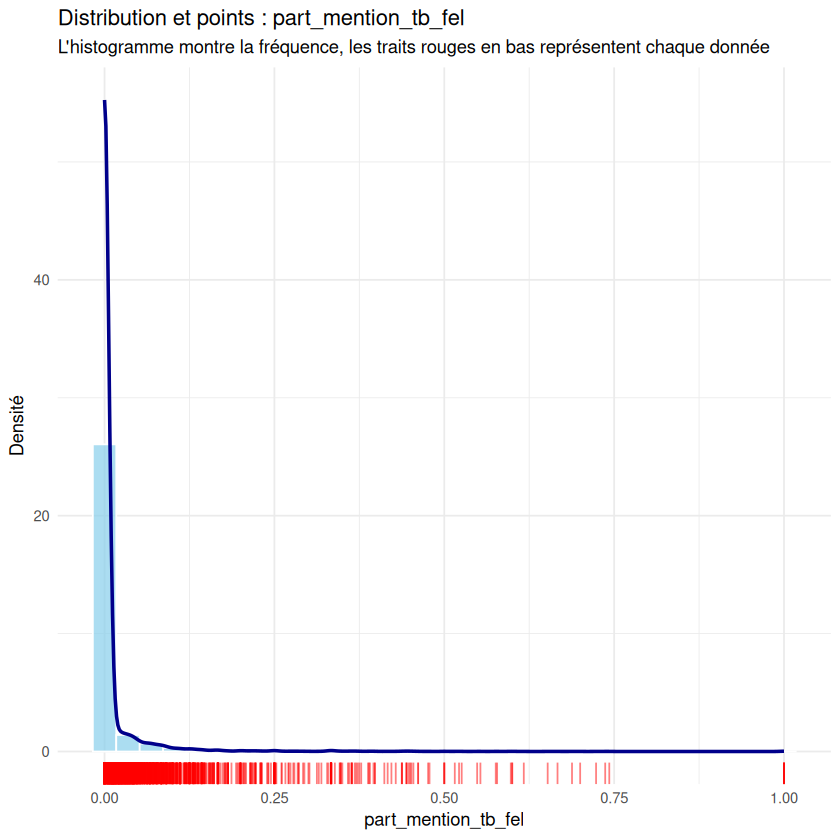

Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


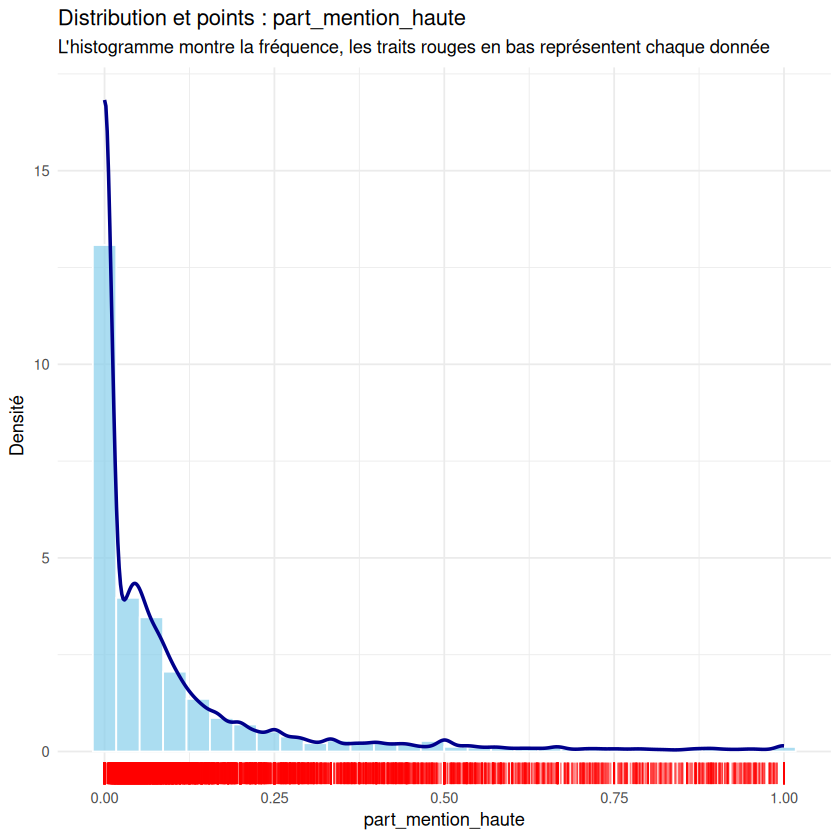

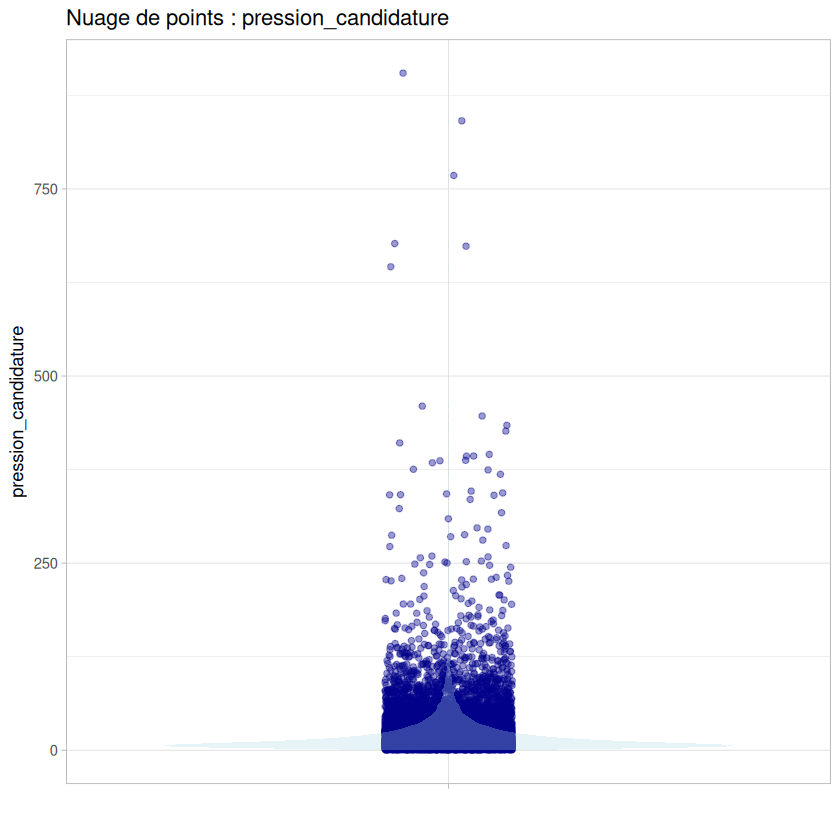

Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


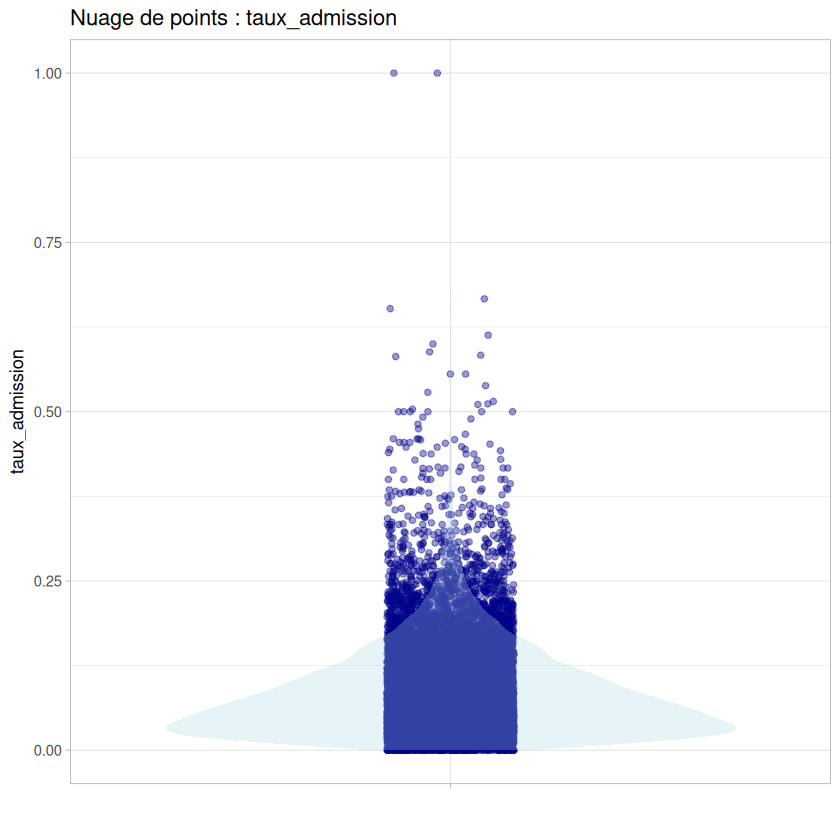

Warning message:
“Removed 1176 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 1176 rows containing missing values or values outside the scale range
(`geom_point()`).”


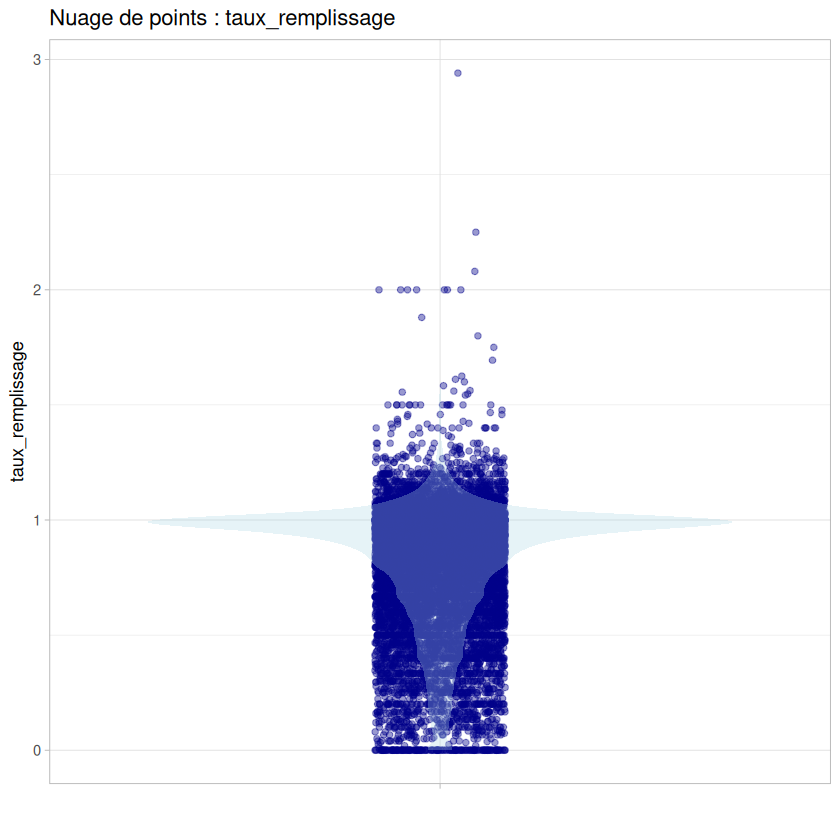

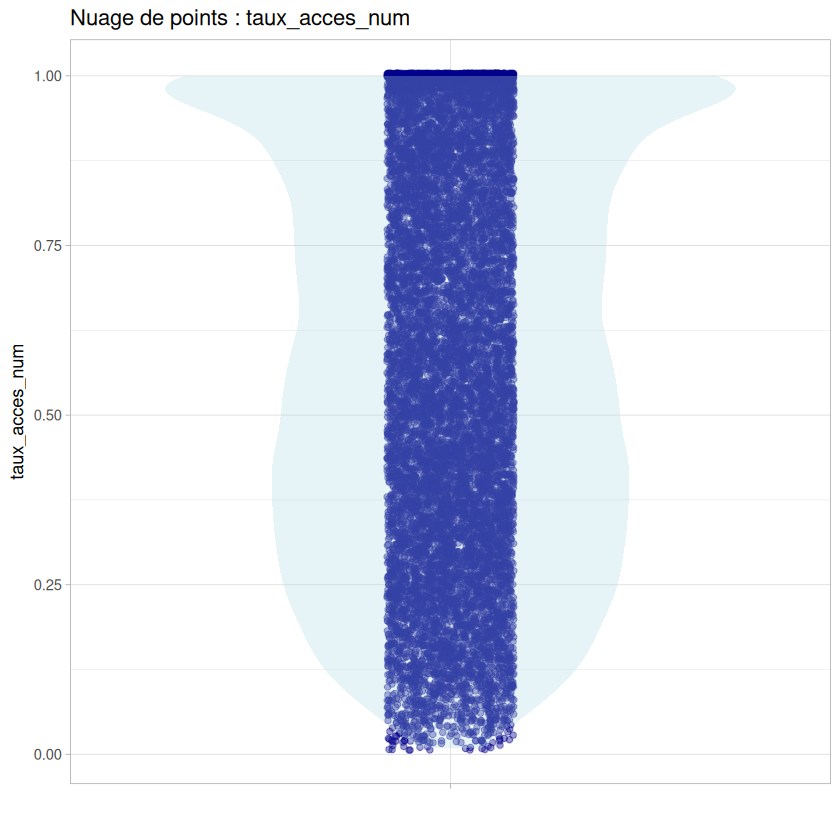

Warning message:
“Removed 179 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 179 rows containing missing values or values outside the scale range
(`geom_point()`).”


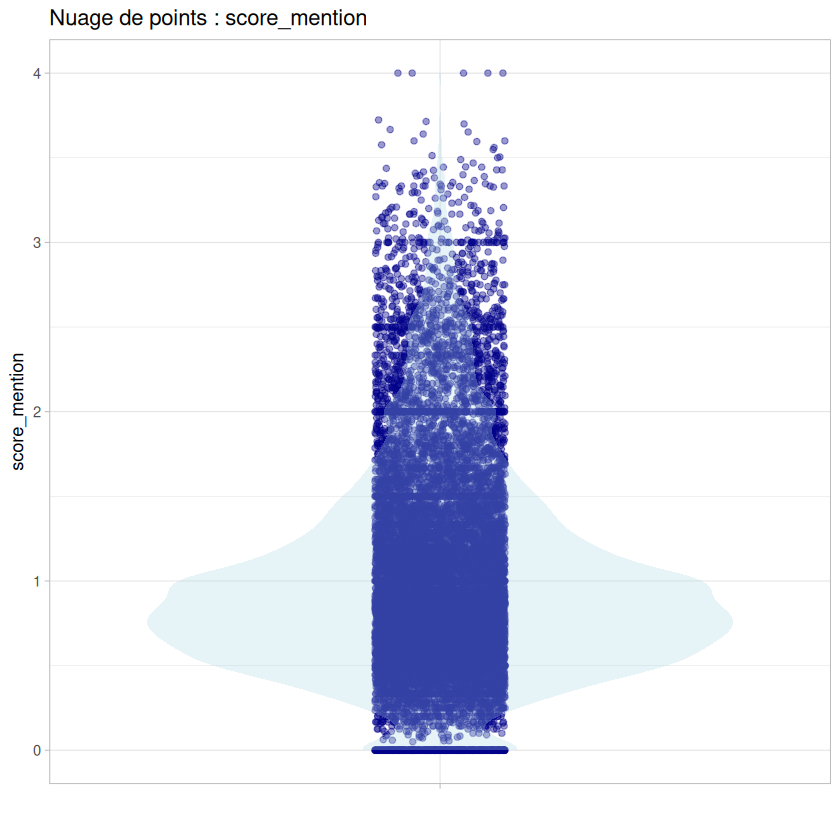

Warning message:
“Removed 179 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 179 rows containing missing values or values outside the scale range
(`geom_point()`).”


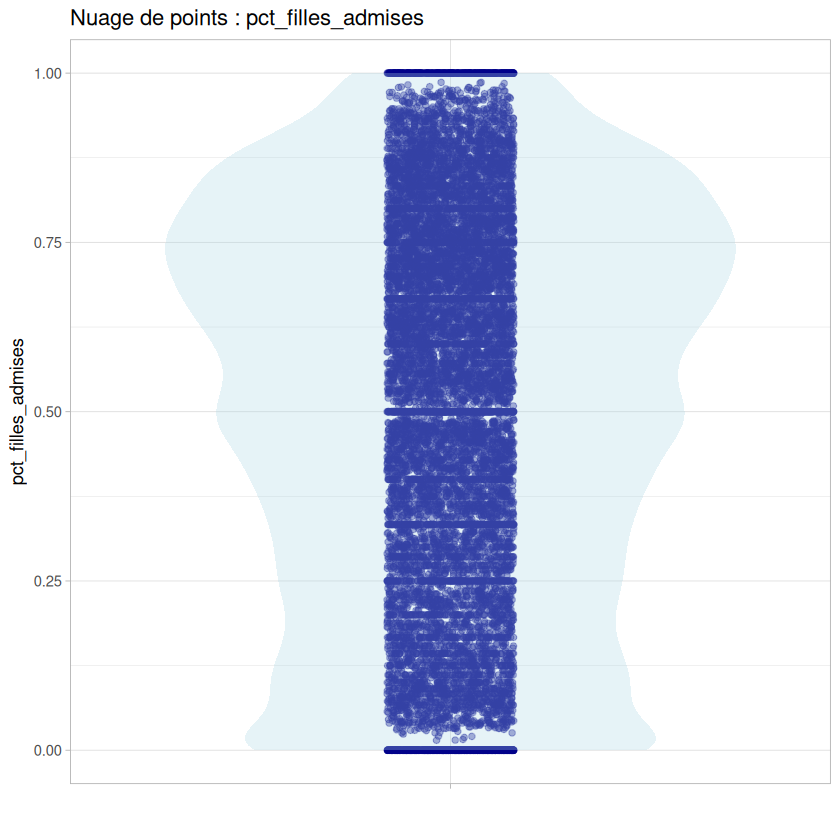

Warning message:
“Removed 298 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 298 rows containing missing values or values outside the scale range
(`geom_point()`).”


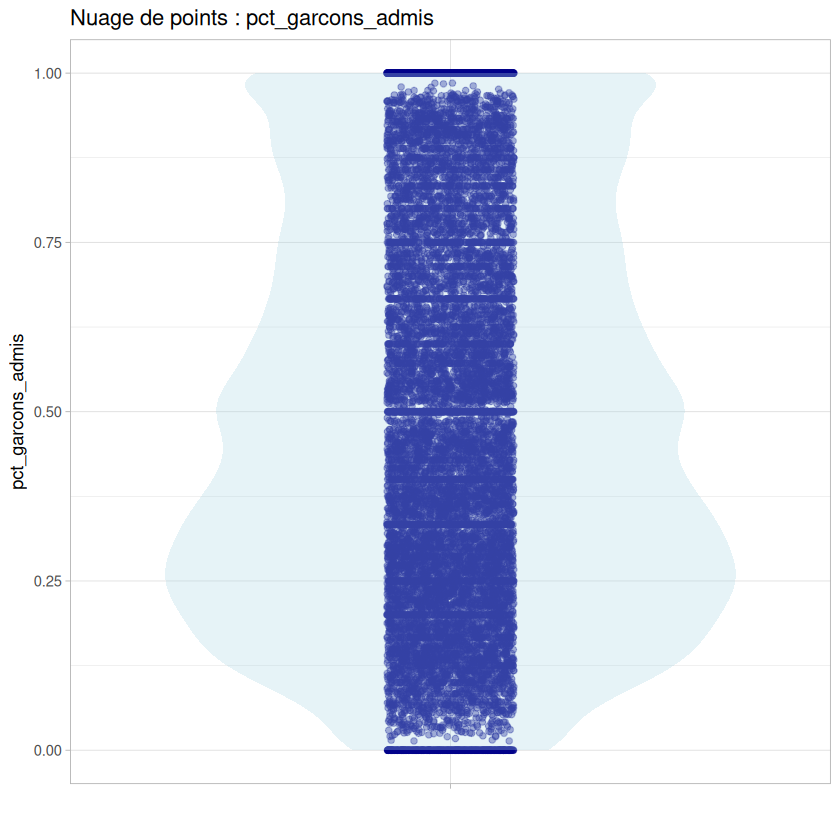

Warning message:
“Removed 298 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 298 rows containing missing values or values outside the scale range
(`geom_point()`).”


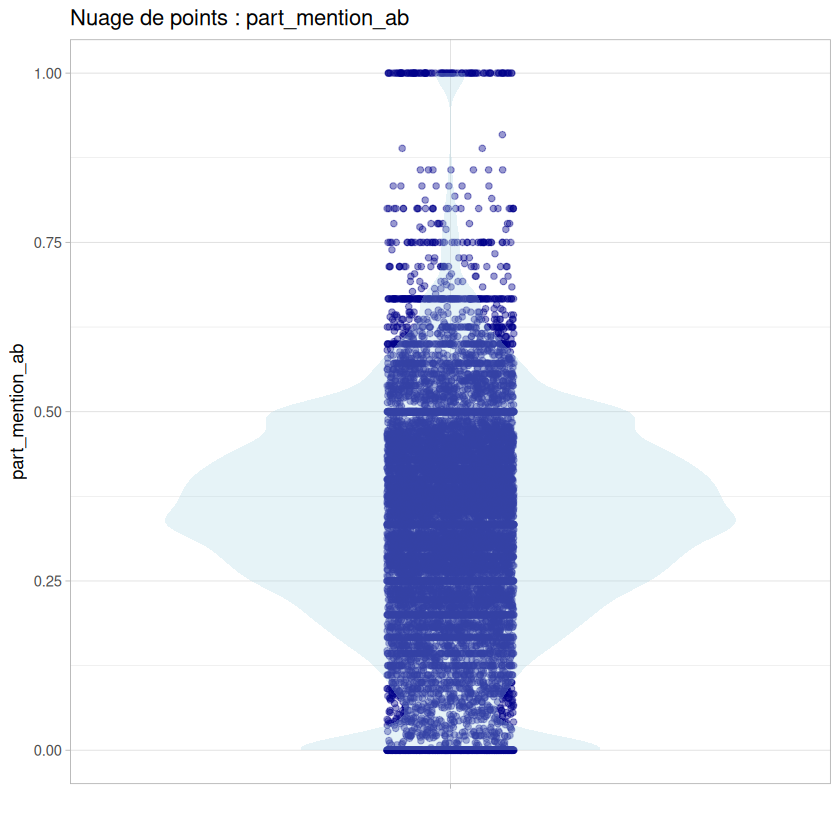

Warning message:
“Removed 298 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 298 rows containing missing values or values outside the scale range
(`geom_point()`).”


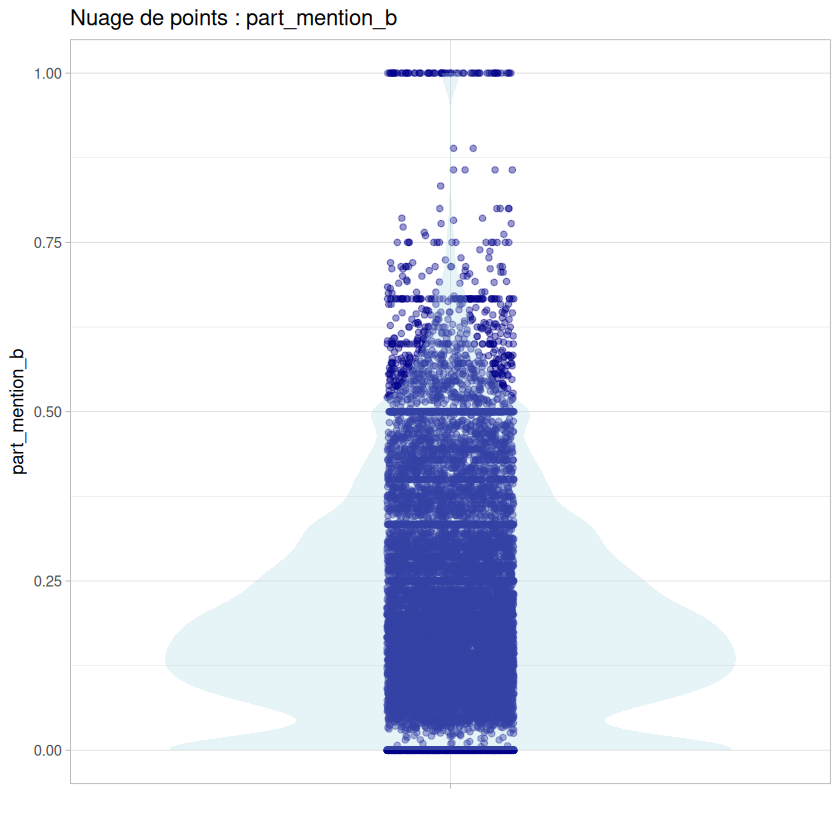

Warning message:
“Removed 298 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 298 rows containing missing values or values outside the scale range
(`geom_point()`).”


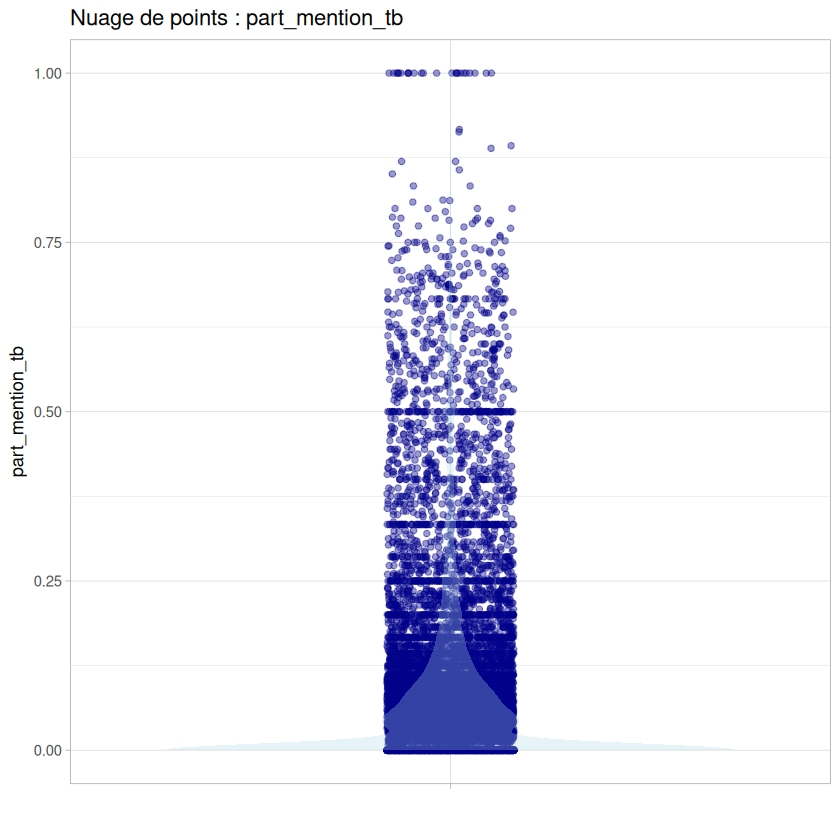

Warning message:
“Removed 298 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 298 rows containing missing values or values outside the scale range
(`geom_point()`).”


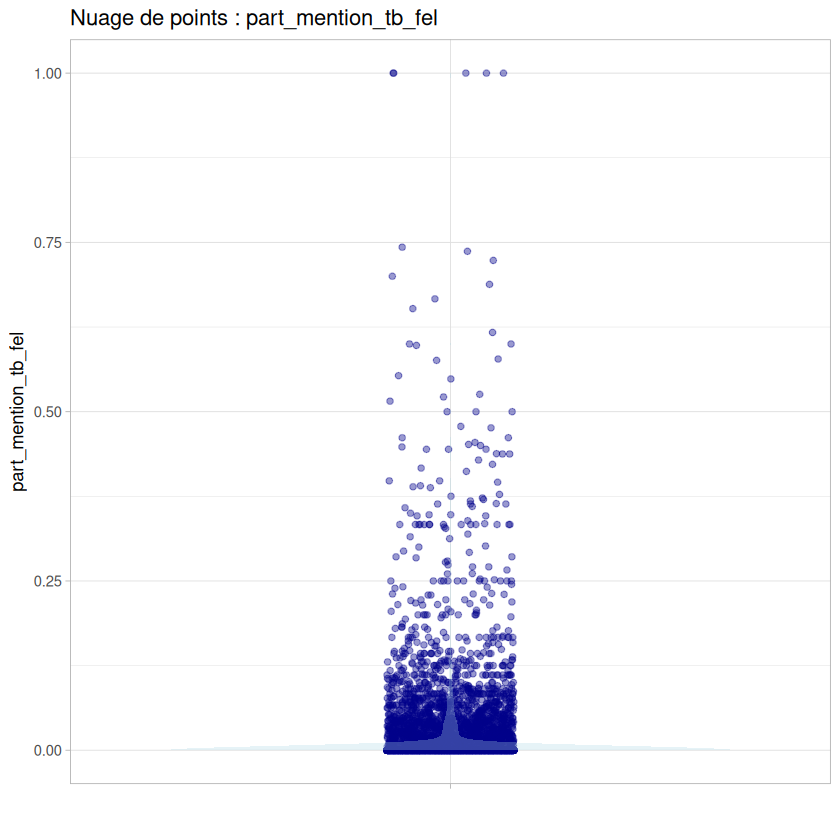

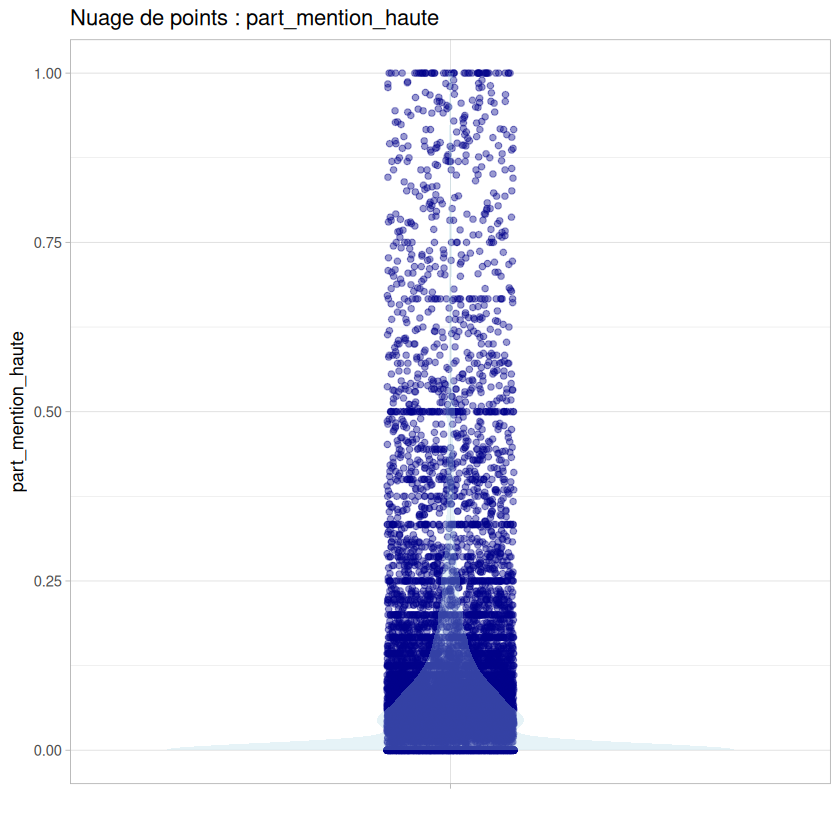

In [22]:
library(ggplot2)

# Liste nettoyée de vos variables
vars_to_plot <- c(
  "pression_candidature", "taux_admission", "taux_remplissage", 
  "taux_acces_num", "score_mention", "pct_filles_admises",
  "pct_garcons_admis", "part_mention_ab", "part_mention_b",
  "part_mention_tb", "part_mention_tb_fel", "part_mention_haute",
  "Effectif.total.candidats.2phases", "Effectif.total.admis.2phases",
  "Capacité.de.l.établissement.par.formation"
)

# Boucle pour générer les distributions + points
for (v in vars_to_plot) {
  
  # Vérification de l'existence de la colonne
  if (v %in% names(data_features_core)) {
    
    p <- ggplot(data_features_core, aes(x = .data[[v]])) +
      # 1. L'histogramme pour la distribution (en bâtons)
      geom_histogram(aes(y = ..density..), bins = 30, 
                     fill = "skyblue", color = "white", alpha = 0.7) +
      # 2. La courbe de densité pour lisser la forme
      geom_density(color = "darkblue", size = 1) +
      # 3. Le "nuage de points" au sol (chaque trait est un établissement)
      geom_rug(alpha = 0.5, color = "red") +
      theme_minimal() +
      labs(
        title = paste("Distribution et points :", v),
        subtitle = "L'histogramme montre la fréquence, les traits rouges en bas représentent chaque donnée",
        x = v,
        y = "Densité"
      )
    
    print(p)
  }
  }# Boucle pour générer les distributions + points
for (v in vars_to_plot) {
  
  # Vérification de l'existence de la colonne
  if (v %in% names(data_features_core)) {
    
    # Remplacer le contenu de la boucle par ceci pour un style "nuage de points vertical"
        p <- ggplot(data_features_core, aes(x = "", y = .data[[v]])) +
            geom_jitter(width = 0.1, alpha = 0.4, color = "darkblue") + # Le nuage de points
            geom_violin(fill = "lightblue", alpha = 0.3, color = NA) +  # La forme de la distribution
            theme_light() +
            labs(title = paste("Nuage de points :", v), x = "", y = v)
    
    print(p)
  }
}

Remarque: pour taux de remplissage on a des valeurs plus grandes que 1 car on accepte plus d'individus qu'il y a de places

In [ ]:
##Analyse du taux de remplissage: 

ERROR: Error in parse(text = input): <text>:2:60: ',' inattendu(e)
1:    # log1p stabilise les variables de volume très asymétriques
2:     log_candidats = log1p(Effectif.total.candidats.2phases),
                                                              ^


# Analyse pluri-dimensionnelle des variables

corrplot 0.95 loaded



                     pct_filles_admises pression_candidature taux_admission
pct_filles_admises                 1.00                 0.11          -0.06
pression_candidature               0.11                 1.00          -0.44
taux_admission                    -0.06                -0.44           1.00
taux_remplissage                   0.14                 0.20          -0.09
score_mention                      0.16                 0.33          -0.30
taux_acces_num                    -0.17                -0.45           0.56
part_mention_tb                    0.11                 0.28          -0.23
                     taux_remplissage score_mention taux_acces_num
pct_filles_admises               0.14          0.16          -0.17
pression_candidature             0.20          0.33          -0.45
taux_admission                  -0.09         -0.30           0.56
taux_remplissage                 1.00          0.22          -0.42
score_mention                    0.22          1.00      

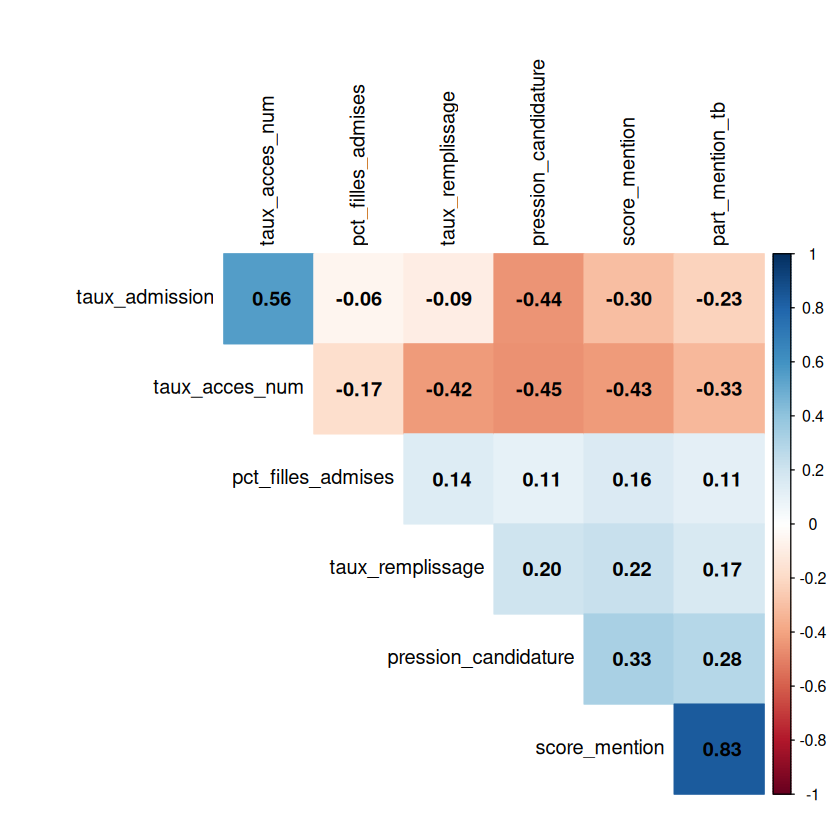

In [ ]:


# Sélectionne les variables numériques pour l'étude
# (On utilise les noms issus du script de nettoyage)
cols_etude <- c(
  "pct_filles_admises", 
  "pression_candidature", 
  "taux_admission", 
  "taux_remplissage", 
  "score_mention", 
  "taux_acces_num",
  "part_mention_tb"  
)

#Calcule la matrice de corrélation
# On utilise use = "complete.obs" pour ignorer les lignes avec des NA
matrice_corr <- cor(data_features_core%>% select(all_of(cols_etude)), use = "complete.obs")

# Affiche la matrice dans la console
print(round(matrice_corr, 2))

# 4. Visualisation graphique (Heatmap)
corrplot(matrice_corr, 
         method = "color",       
         type = "upper",         
         order = "hclust",       
         addCoef.col = "black",  
         tl.col = "black",       
         diag = FALSE            
)

Remarques: 
Pas un lien important entre mention et pression candidature  
la pression candidature est en revanche liée au taux accès 

`geom_smooth()` using formula = 'y ~ x'


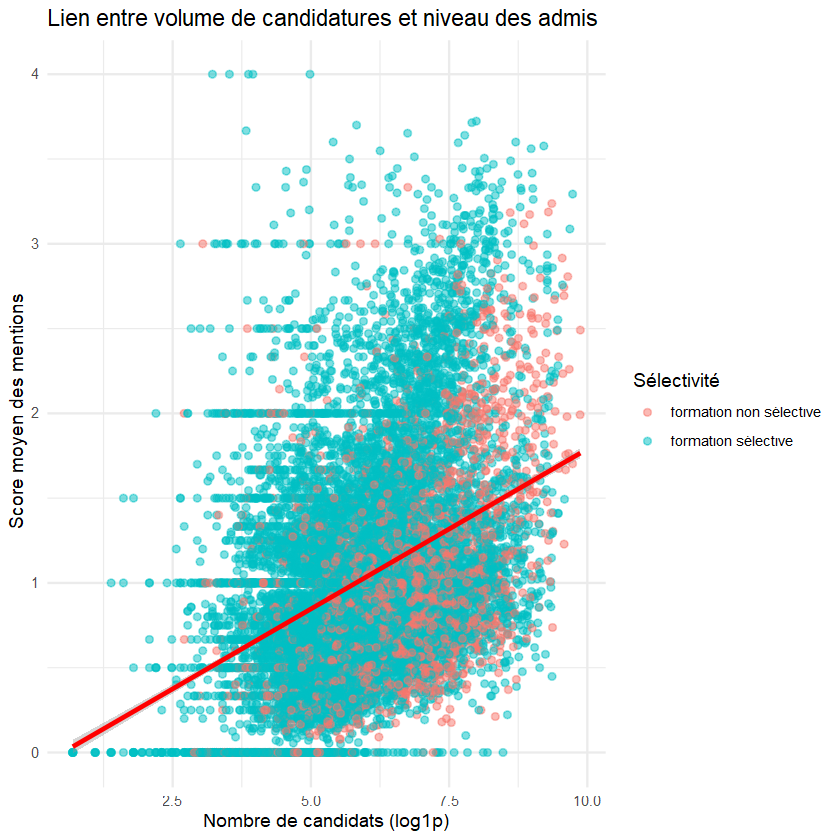

In [ ]:
###Corrélation : Pression vs Niveau académique (Score Mention)

ggplot(data_features_core, aes(x = log_candidats, y = score_mention)) +
  geom_point(aes(color = Sélectivité), alpha = 0.5) +
  geom_smooth(method = "lm", color = "red") +
  labs(
    title = "Lien entre volume de candidatures et niveau des admis",
    x = "Nombre de candidats (log1p)",
    y = "Score moyen des mentions"
  ) +
  theme_minimal()

Plus il y a de candidats pour une formation plus leurs notes sont élevée en moyenne  (droite de régression rouge)
entre mentions 3 et 4 (bien/très bien) seulement des formations sélectives semblent être demandées

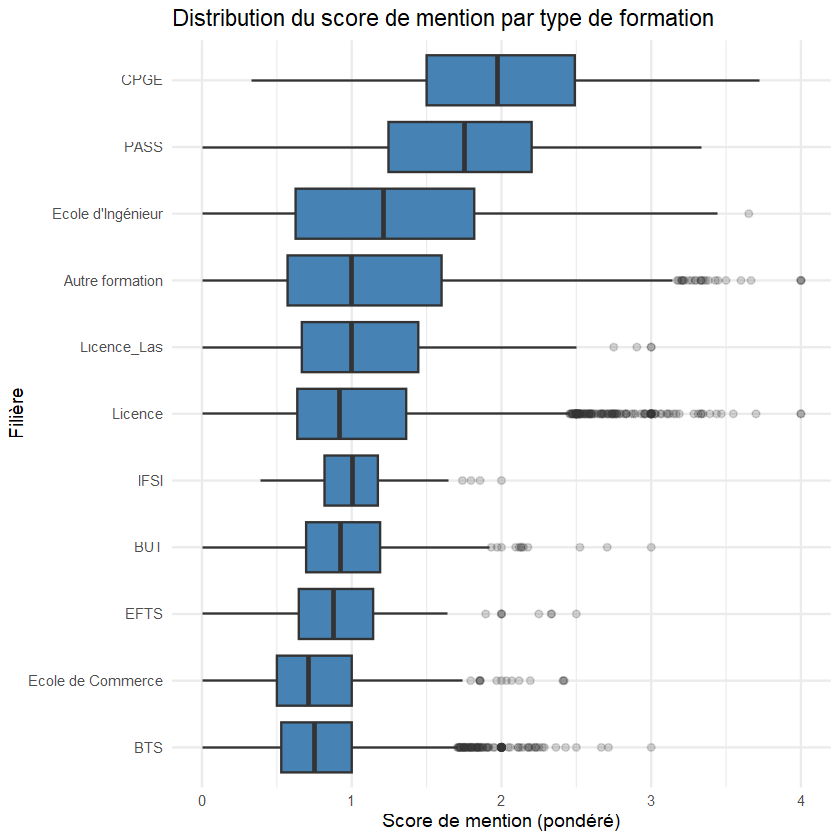

In [ ]:
#Niveau admis par fillières
ggplot(data_features_core, aes(x = reorder(Filière.de.formation.très.agrégée, score_mention), y = score_mention)) +
  geom_boxplot(fill = "steelblue", outlier.alpha = 0.2) +
  coord_flip() + # Pour lire les noms des filières horizontalement
  labs(
    title = "Distribution du score de mention par type de formation",
    x = "Filière",
    y = "Score de mention (pondéré)"
  ) +
  theme_minimal()

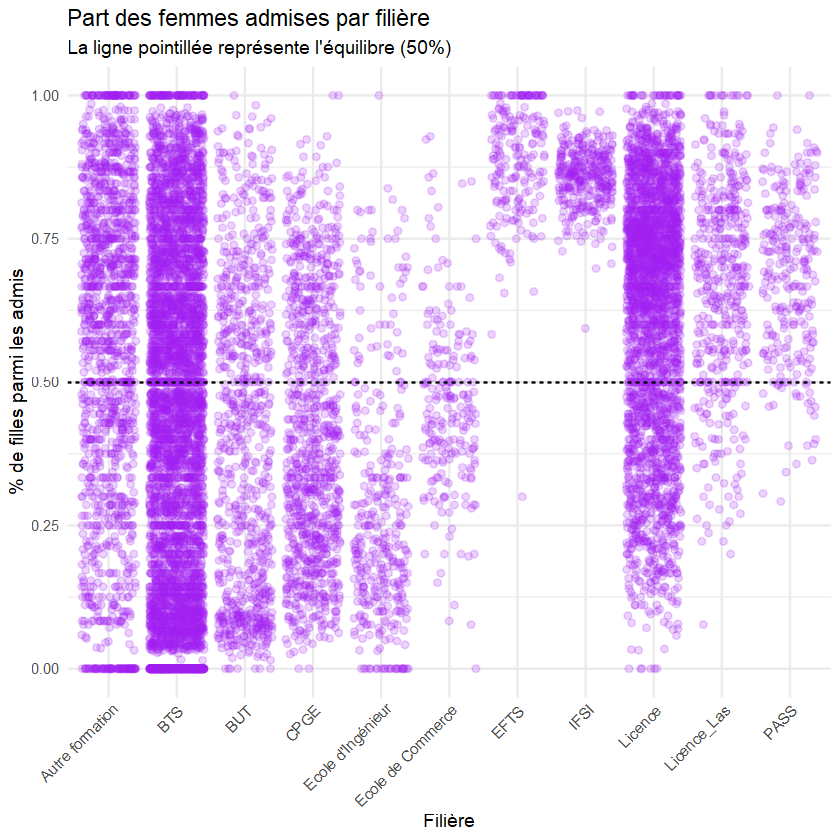

In [ ]:
#Mixité par domaine
data_genre <- data_features_core %>%
  filter(log_admis > 2) # On filtre les petites formations pour la lisibilité

ggplot(data_genre, aes(x = Filière.de.formation.très.agrégée, y = pct_filles_admises)) +
  geom_jitter(alpha = 0.2, color = "purple") + 
  # CORRECTION ICI : yintercept au lieu de y0
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "black") + 
  labs(
    title = "Part des femmes admises par filière",
    subtitle = "La ligne pointillée représente l'équilibre (50%)",
    x = "Filière",
    y = "% de filles parmi les admis"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."
Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>."
Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>."


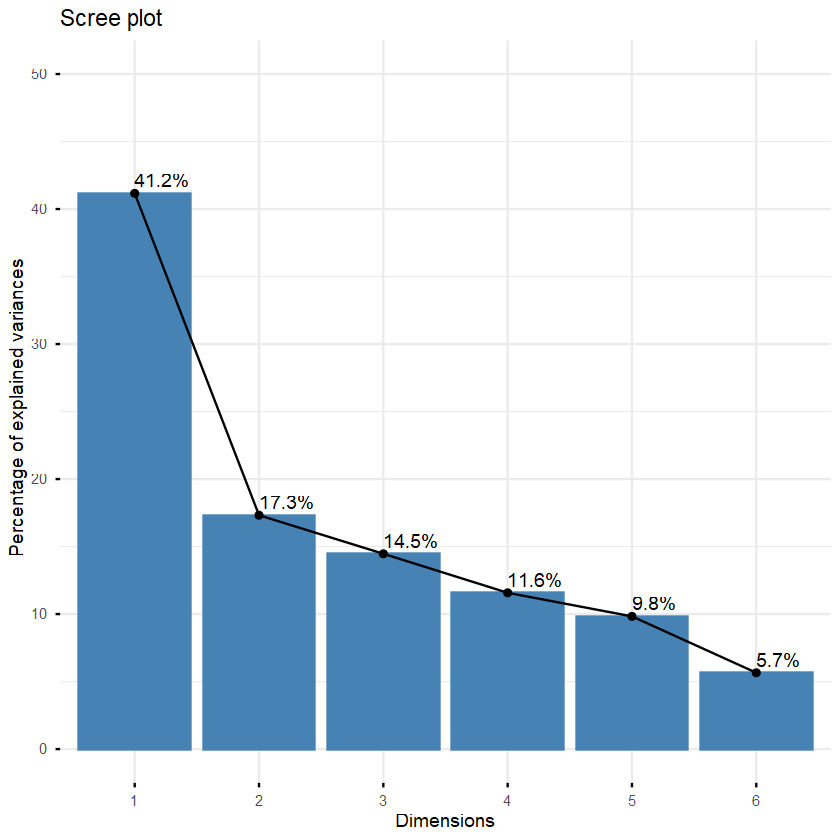

Warning message in PCA(data_pca_full, quali.sup = which(names(data_pca_full) == :
"Missing values are imputed by the mean of the variable: you should use the imputePCA function of the missMDA package"
Warning message in mean.default(X[, j], na.rm = TRUE):
"l'argument n'est ni numérique, ni logique : renvoi de NA"
Warning message in mean.default(X[, j], na.rm = TRUE):
"l'argument n'est ni numérique, ni logique : renvoi de NA"
Warning message in mean.default(X[, j], na.rm = TRUE):
"l'argument n'est ni numérique, ni logique : renvoi de NA"
Warning message in mean.default(X[, j], na.rm = TRUE):
"l'argument n'est ni numérique, ni logique : renvoi de NA"
Warning message in mean.default(X[, j], na.rm = TRUE):
"l'argument n'est ni numérique, ni logique : renvoi de NA"


ERROR: Error in PCA(data_pca_full, quali.sup = which(names(data_pca_full) == : 
The following variables are not quantitative:  Établissement
The following variables are not quantitative:  Filière.de.formation
The following variables are not quantitative:  Filière.de.formation.très.agrégée
The following variables are not quantitative:  Région.de.l.établissement
The following variables are not quantitative:  Académie.de.l.établissement


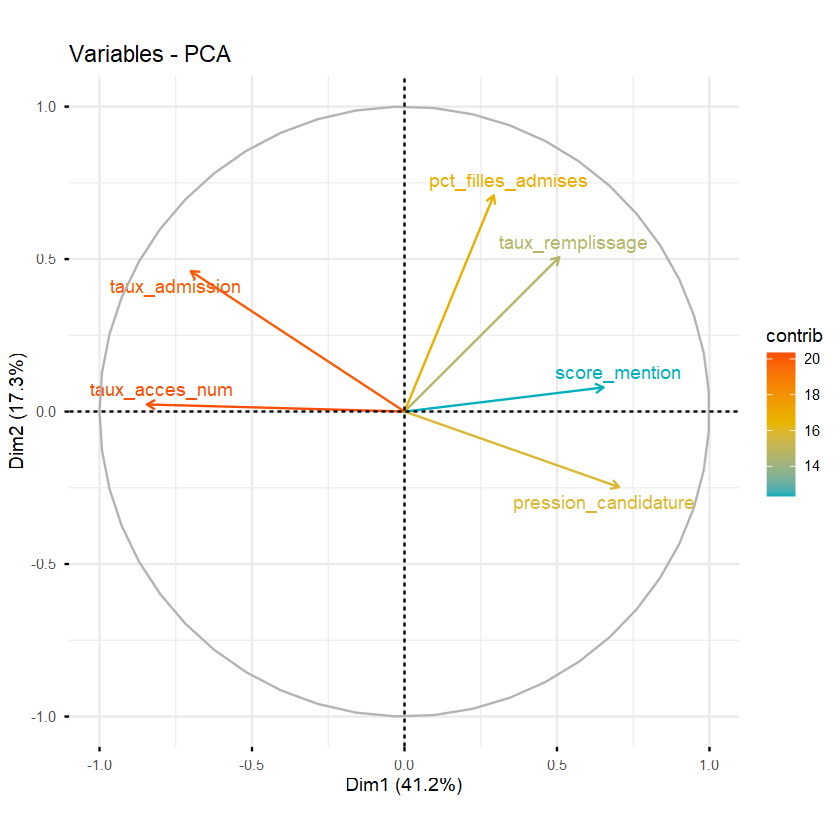

In [ ]:
###ACP
library(FactoMineR)
library(factoextra)
library(tidyr)

# 1. Sélection des variables actives pour l'ACP
# On choisit des ratios plutôt que des volumes bruts pour éviter l'effet de taille
data_pca <- data_features_core %>%
  select(
    pression_candidature, 
    taux_admission, 
    taux_remplissage, 
    taux_acces_num, 
    score_mention, 
    pct_filles_admises
  ) %>%
  drop_na() # L'ACP nécessite des données complètes

# 2. Exécution de l'ACP
# Les données sont centrées et réduites par défaut (scale.unit = TRUE)
res_pca <- PCA(data_pca, graph = FALSE)

fviz_eig(res_pca, addlabels = TRUE, ylim = c(0, 50))


fviz_pca_var(res_pca, col.var = "contrib", 
             gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
             repel = TRUE)


# On récupère les données sans NA pour pouvoir rattacher la variable qualitative Sélectivité
data_pca_full <- data_features_core %>%
  drop_na(pression_candidature, taux_admission, taux_remplissage, 
          taux_acces_num, score_mention, pct_filles_admises)

# ACP avec la Sélectivité en variable illustrative
res_pca_full <- PCA(data_pca_full, 
                    quali.sup = which(names(data_pca_full) == "Sélectivité"), 
                    graph = FALSE)

fviz_pca_ind(res_pca_full, 
             geom.ind = "point", 
             col.ind = data_pca_full$Sélectivité, 
             palette = "jco",
             addEllipses = TRUE, 
             legend.title = "Sélectivité")